# Phase 2 — Preprocessing (SFCN-compatible)

## 1. Install preprocessing packages

In [1]:
%pip -q install antspyx antspynet nibabel nilearn scikit-learn
print('Packages ready.')

Note: you may need to restart the kernel to use updated packages.
Packages ready.


In [2]:
import sys
import os

print("Python:", sys.version)
print("Executable:", sys.executable)
print("CPU threads:", os.cpu_count())

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Executable: c:\Users\jaaiw\Desktop\3rd_year_projects\ml_brain\brainage-env\Scripts\python.exe
CPU threads: 20


## 2. Reconnect to the Phase 1 project directory

In [4]:
from pathlib import Path
import pandas as pd



PROJECT_DIR = Path(r"G:\My Drive\ML_Project")

DATA_DIR = PROJECT_DIR / "IXI_data"
PREPROCESSED_DIR = PROJECT_DIR / "IXI_preprocessed"
metadata_path = PROJECT_DIR / "ixi_final_metadata.csv"

PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("Preprocessed directory:", PREPROCESSED_DIR)



if not PROJECT_DIR.exists():
    raise FileNotFoundError(f"Project directory not found: {PROJECT_DIR}")

if not DATA_DIR.exists():
    raise FileNotFoundError(f"IXI_data folder not found: {DATA_DIR}")

if not metadata_path.exists():
    raise FileNotFoundError(f"Metadata not found: {metadata_path}")



final_df = pd.read_csv(metadata_path)

print(f"Loaded metadata for {len(final_df)} subjects.")



def get_local_path(old_path):
    filename = Path(str(old_path)).name
    return DATA_DIR / filename

final_df["file_path"] = final_df["file_path"].apply(get_local_path)



missing_files = [
    p for p in final_df["file_path"]
    if not p.exists()
]

if missing_files:
    print(f"Missing scans: {len(missing_files)}")
    print("Examples:")
    for p in missing_files[:5]:
        print(p)

    raise FileNotFoundError(
        f"{len(missing_files)} scans listed in metadata are missing."
    )

print(f"All {len(final_df)} MRI files found.")


existing = list(PREPROCESSED_DIR.glob("IXI*.npy"))

print(f"Existing preprocessed scans: {len(existing)}")

final_df.head()

Project directory: G:\My Drive\ML_Project
Data directory: G:\My Drive\ML_Project\IXI_data
Preprocessed directory: G:\My Drive\ML_Project\IXI_preprocessed
Loaded metadata for 499 subjects.
All 499 MRI files found.
Existing preprocessed scans: 498


,IXI_ID,site,filename,file_path,SEX,AGE,sex_label
0,2,Guys,IXI002-Guys-0828-T1.nii,G:\My Drive\ML_Project\IXI_data\IXI002-Guys-08...,1,46.710472,Male
1,12,HH,IXI012-HH-1211-T1.nii,G:\My Drive\ML_Project\IXI_data\IXI012-HH-1211...,2,37.697467,Female
2,13,HH,IXI013-HH-1212-T1.nii,G:\My Drive\ML_Project\IXI_data\IXI013-HH-1212...,2,29.779603,Female
3,14,HH,IXI014-HH-1236-T1.nii,G:\My Drive\ML_Project\IXI_data\IXI014-HH-1236...,2,34.477755,Female
4,15,HH,IXI015-HH-1258-T1.nii,G:\My Drive\ML_Project\IXI_data\IXI015-HH-1258...,1,30.417522,Male


## 3. Prepare the MNI152 1mm registration target

In [5]:
import ants
import nibabel as nib
from nilearn.datasets import load_mni152_template

mni_nib = load_mni152_template(resolution=1)

mni_path = "/tmp/MNI152_T1_1mm.nii.gz"
nib.save(mni_nib, mni_path)

mni_template = ants.image_read(mni_path)

print(f"MNI152 template shape: {mni_template.shape}")
print(f"Spacing: {mni_template.spacing}")

MNI152 template shape: (197, 233, 189)
Spacing: (1.0, 1.0, 1.0)


## 4. Define the preprocessing pipeline

Steps: N4 bias correction → affine registration to MNI152 → skull-strip → center-crop/pad to 160×192×160 → intensity normalize.

In [6]:
import numpy as np
import antspynet

TARGET_SHAPE = (160, 192, 160)

def center_crop_or_pad(volume, target_shape):
    result = volume
    for axis, target in enumerate(target_shape):
        current = result.shape[axis]
        if current > target:
            start = (current - target) // 2
            result = np.take(result, range(start, start + target), axis=axis)
        elif current < target:
            pad_before = (target - current) // 2
            pad_after = target - current - pad_before
            pad_width = [(0, 0)] * result.ndim
            pad_width[axis] = (pad_before, pad_after)
            result = np.pad(result, pad_width, mode='constant', constant_values=0)
    return result

def preprocess_scan(scan_path):
    raw = ants.image_read(str(scan_path))
    bias_corrected = ants.n4_bias_field_correction(raw)

    registration = ants.registration(fixed=mni_template, moving=bias_corrected, type_of_transform='Affine')
    registered = registration['warpedmovout']

    brain_mask_prob = antspynet.brain_extraction(registered, modality='t1')
    brain_mask = ants.threshold_image(brain_mask_prob, 0.5, 1.0, 1, 0)
    skull_stripped = registered * brain_mask

    volume = skull_stripped.numpy()
    brain_voxels = volume[volume > 0]
    if brain_voxels.size == 0:
        raise ValueError('Skull-stripping produced an empty brain mask.')
    low, high = np.percentile(brain_voxels, [1, 99])
    volume = np.clip(volume, low, high)
    volume = (volume - low) / max(high - low, 1e-6)

    volume = center_crop_or_pad(volume, TARGET_SHAPE)
    return volume.astype(np.float32)

## 5. Run the pipeline over the full cohort

Resume-safe: scans already preprocessed on a previous run are skipped. Failures are logged rather than stopping the whole batch.

In [7]:
failures = []
processed_paths = {}

for _, row in final_df.iterrows():
    ixi_id = int(row['IXI_ID'])
    out_path = PREPROCESSED_DIR / f'IXI{ixi_id:03d}.npy'
    if out_path.exists():
        processed_paths[ixi_id] = str(out_path)
        continue
    try:
        volume = preprocess_scan(row['file_path'])
        np.save(out_path, volume)
        processed_paths[ixi_id] = str(out_path)
    except Exception as exc:
        failures.append({'IXI_ID': ixi_id, 'file_path': row['file_path'], 'error': str(exc)})
        print(f'Failed on IXI{ixi_id:03d}: {exc}')

print(f'Preprocessed {len(processed_paths)}/{len(final_df)} subjects. {len(failures)} failures.')

Preprocessed 499/499 subjects. 0 failures.


In [8]:
final_df['preprocessed_path'] = final_df['IXI_ID'].map(processed_paths)
usable_df = final_df.dropna(subset=['preprocessed_path']).reset_index(drop=True)

if failures:
    failures_path = PROJECT_DIR / 'phase2_preprocessing_failures.csv'
    pd.DataFrame(failures).to_csv(failures_path, index=False)
    print(f'Logged {len(failures)} failures to {failures_path}')

usable_df.to_csv(PROJECT_DIR / 'ixi_preprocessed_metadata.csv', index=False)
print(f'{len(usable_df)} subjects have a usable preprocessed scan.')

499 subjects have a usable preprocessed scan.


## 6. Build the train/val/test split (stratified by sex + site)

In [9]:
from sklearn.model_selection import train_test_split

usable_df['strata'] = usable_df['site'].astype(str) + '_' + usable_df['sex_label'].astype(str)
strata_counts = usable_df['strata'].value_counts()
rare_strata = strata_counts[strata_counts < 2].index.tolist()
if rare_strata:
    print(f'Strata with <2 members (cannot be split with stratification): {rare_strata}')

stratify_col = usable_df['strata'].where(~usable_df['strata'].isin(rare_strata), 'other')

train_df, temp_df = train_test_split(
    usable_df, test_size=0.30, stratify=stratify_col, random_state=42
)
temp_stratify = stratify_col.loc[temp_df.index]
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_stratify, random_state=42
)

for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    split_df.drop(columns=['strata']).to_csv(PROJECT_DIR / f'ixi_{name}.csv', index=False)
    print(f'{name}: {len(split_df)} subjects')

print('\nSplit breakdown by site/sex:')
print(pd.concat({
    'train': train_df.groupby(['site', 'sex_label']).size(),
    'val': val_df.groupby(['site', 'sex_label']).size(),
    'test': test_df.groupby(['site', 'sex_label']).size(),
}, axis=1).fillna(0).astype(int))

train: 349 subjects
val: 75 subjects
test: 75 subjects

Split breakdown by site/sex:
                train  val  test
site sex_label                  
Guys Female       109   23    24
     Male          88   19    19
HH   Female        59   13    12
     Male          46   10    10
IOP  Female        27    5     6
     Male          20    5     4


## 7. Spot-check preprocessing on a few examples

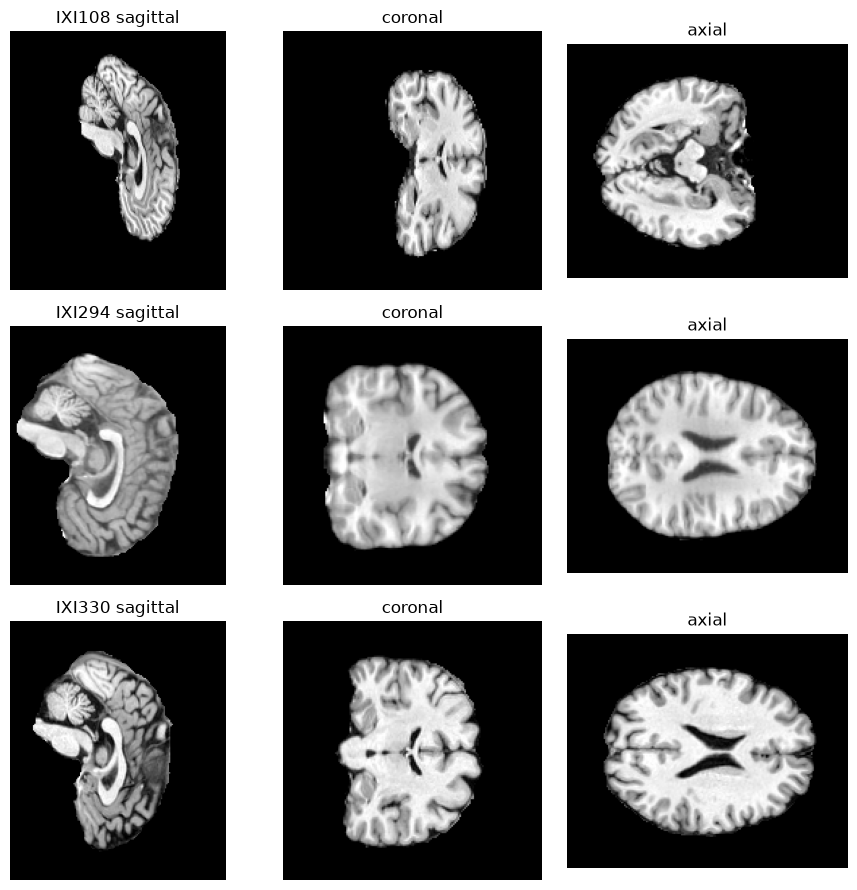

Spot-check plot saved to G:\My Drive\ML_Project\phase2_preprocessing_spotcheck.png


In [10]:
import matplotlib.pyplot as plt

sample_ids = usable_df['IXI_ID'].sample(min(3, len(usable_df)), random_state=0).tolist()
fig, axes = plt.subplots(len(sample_ids), 3, figsize=(9, 3 * len(sample_ids)))
if len(sample_ids) == 1:
    axes = axes[None, :]

for row_idx, ixi_id in enumerate(sample_ids):
    volume = np.load(processed_paths[ixi_id])
    cx, cy, cz = (s // 2 for s in volume.shape)
    axes[row_idx, 0].imshow(volume[cx, :, :], cmap='gray'); axes[row_idx, 0].set_title(f'IXI{ixi_id:03d} sagittal')
    axes[row_idx, 1].imshow(volume[:, cy, :], cmap='gray'); axes[row_idx, 1].set_title('coronal')
    axes[row_idx, 2].imshow(volume[:, :, cz], cmap='gray'); axes[row_idx, 2].set_title('axial')
    for ax in axes[row_idx]:
        ax.axis('off')

plt.tight_layout()
plot_path = PROJECT_DIR / 'phase2_preprocessing_spotcheck.png'
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Spot-check plot saved to {plot_path}')

## 8. Summary

In [11]:
print(f'Total subjects (Phase 1): {len(final_df)}')
print(f'Successfully preprocessed: {len(usable_df)}')
print(f'Failed: {len(failures)}')
print(f'Train / Val / Test sizes: {len(train_df)} / {len(val_df)} / {len(test_df)}')
print(f'Preprocessed scans saved under: {PREPROCESSED_DIR}')
print(f'Split CSVs saved to: {PROJECT_DIR}')

Total subjects (Phase 1): 499
Successfully preprocessed: 499
Failed: 0
Train / Val / Test sizes: 349 / 75 / 75
Preprocessed scans saved under: G:\My Drive\ML_Project\IXI_preprocessed
Split CSVs saved to: G:\My Drive\ML_Project
